In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [ ]:
csv_path = '/content/drive/MyDrive/dataset/autoencoder_regression_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)
data = df.to_numpy()

# Display shape
print("Shape:", df.shape)
df.head()

Shape: (98664, 18)


,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,-6.900868,-2.257141,0.207701,4.832452,3.164491,-3.497359,-0.399868,-3.593274,1.658348,17.176982,3327.875478,-3.855474,-3.844470,-8.889865,-4.018888,-3.195541,-7.868857,-5.895533
1,-1.916458,-3.192332,-2.223765,5.931571,4.592133,-4.370333,0.607382,-0.963816,0.258443,16.036432,2034.071133,-3.014919,-2.962217,-3.225697,-2.038615,-5.329029,-3.169883,-3.206833
2,-2.968401,-4.461657,0.615572,6.173611,3.366025,-3.686306,1.251608,-2.651082,0.503774,9.066010,1712.661454,-2.246068,-1.677456,-3.993484,-2.895214,-7.397882,-8.908273,-7.172669
3,-6.847833,-1.085600,1.159278,6.646182,2.965960,-3.345752,1.183463,-3.545845,0.562965,7.254639,3287.260930,-1.086659,-3.761693,-8.448541,-3.301345,-4.516020,-7.289866,-7.753208
4,-6.317009,-2.666278,0.357277,5.979415,3.764004,-3.740373,0.478526,-2.697041,0.745250,35.230361,2895.010899,-1.323324,-1.794849,-8.350682,-4.666140,-6.680365,-6.197769,-5.475105


In [ ]:
df.describe()

,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
count,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000
mean,0.432125,-3.457424,-3.516597,3.565911,4.389943,-3.945479,0.114160,-1.418761,1.060991,22.680367,1990.529089,-3.203587,-1.506352,-5.497066,-5.490777,-5.500600,-5.500026,-5.508865
std,3.234254,1.967700,3.186135,1.796521,1.560807,1.812092,2.572931,1.960795,0.542885,10.043365,866.480792,2.187283,1.445999,2.021719,2.020946,2.027659,2.023330,2.020505
min,-14.811619,-15.821565,-34.447407,-10.412514,-0.998671,-8.042172,-17.367699,-17.314592,0.100042,5.000412,500.059513,-6.999982,-3.999971,-8.999924,-8.999969,-8.999911,-8.999990,-8.999985
25%,-1.607159,-4.582289,-4.866113,2.445690,3.396904,-5.127968,-1.442510,-2.488036,0.593661,14.036827,1238.898762,-5.087822,-2.762471,-7.250021,-7.239419,-7.264763,-7.260083,-7.261356
50%,1.228101,-3.437524,-2.951968,3.444859,4.215981,-4.415377,0.642672,-1.233767,1.061147,22.724996,1986.033911,-3.215291,-1.504305,-5.488896,-5.485339,-5.499874,-5.502937,-5.508495
75%,2.808834,-2.111875,-1.699876,4.814338,5.243215,-3.260385,2.143631,-0.132477,1.531775,31.344526,2737.571477,-1.317402,-0.255494,-3.753459,-3.741738,-3.740803,-3.745523,-3.763974
max,8.470268,1.421151,3.338503,8.002897,16.989565,12.363155,5.335825,3.258902,1.999990,39.999593,3499.933503,0.599861,0.999957,-2.000011,-2.000260,-2.000041,-2.000107,-2.000021


In [ ]:
target_cols = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]
X = df.drop(columns=target_cols)
y = df[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (98664, 13)
y shape: (98664, 5)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# Scale inputs
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

# Scale outputs (independently for each parameter!)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_val   = scaler_y.transform(y_val)
y_test  = scaler_y.transform(y_test)

In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(len(target_cols))
])


model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='mse',
              metrics=['mae'])


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,597 (182.02 KB)

 Trainable params: 45,829 (179.02 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.5719 - mae: 0.5733 - val_loss: 0.2860 - val_mae: 0.4011 - learning_rate: 5.0000e-04
Epoch 2/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2809 - mae: 0.3942 - val_loss: 0.2320 - val_mae: 0.3483 - learning_rate: 5.0000e-04
Epoch 3/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2383 - mae: 0.3551 - val_loss: 0.2058 - val_mae: 0.3256 - learning_rate: 5.0000e-04
Epoch 4/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.2154 - mae: 0.3334 - val_loss: 0.1914 - val_mae: 0.3060 - learning_rate: 5.0000e-04
Epoch 5/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2007 - mae: 0.3187 - val_loss: 0.1766 - val_mae: 0.2940 - learning_rate: 5.0000e-04
Epoch 6/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1885 - mae: 0.3059 - val_loss: 0.1687 - val_mae: 0.2858 - learning_rate: 5.0000e-04
Epoch 7/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1824 - mae: 0.2981 - val_loss: 0.1623 - val_mae: 0.277

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 0.09012431651353836
Test MAE: 0.18865342438220978


In [ ]:
y_pred = model.predict(X_test)
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print("\n Metrics per Atmospheric Parameter:")
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test_rescaled[:, i], y_pred_rescaled[:, i]))
    mae  = mean_absolute_error(y_test_rescaled[:, i], y_pred_rescaled[:, i])
    r2   = r2_score(y_test_rescaled[:, i], y_pred_rescaled[:, i])
    print(f"{col}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")


 Metrics per Atmospheric Parameter:
log_H2O: RMSE=0.596, MAE=0.386, R²=0.914
log_CO2: RMSE=0.263, MAE=0.173, R²=0.983
log_CO: RMSE=0.845, MAE=0.594, R²=0.826
log_CH4: RMSE=0.562, MAE=0.354, R²=0.923
log_NH3: RMSE=0.625, MAE=0.401, R²=0.903


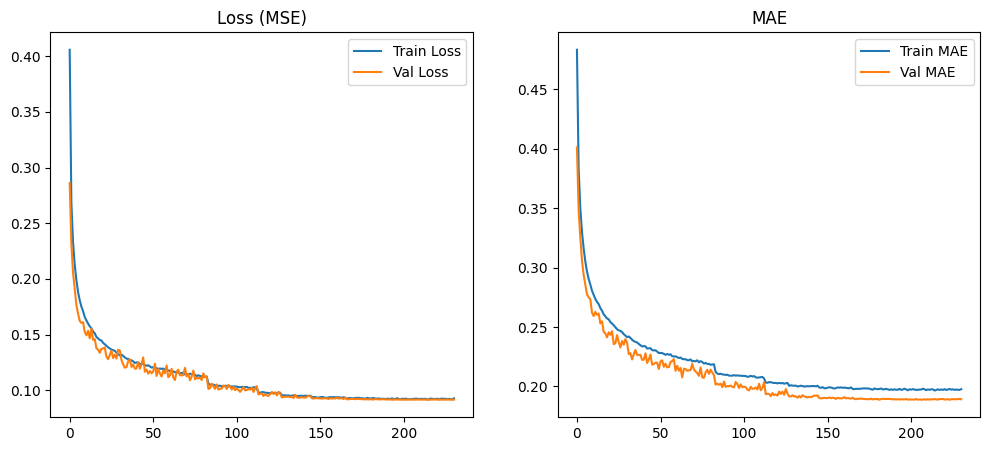

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss (MSE)")

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend(); plt.title("MAE")
plt.show()

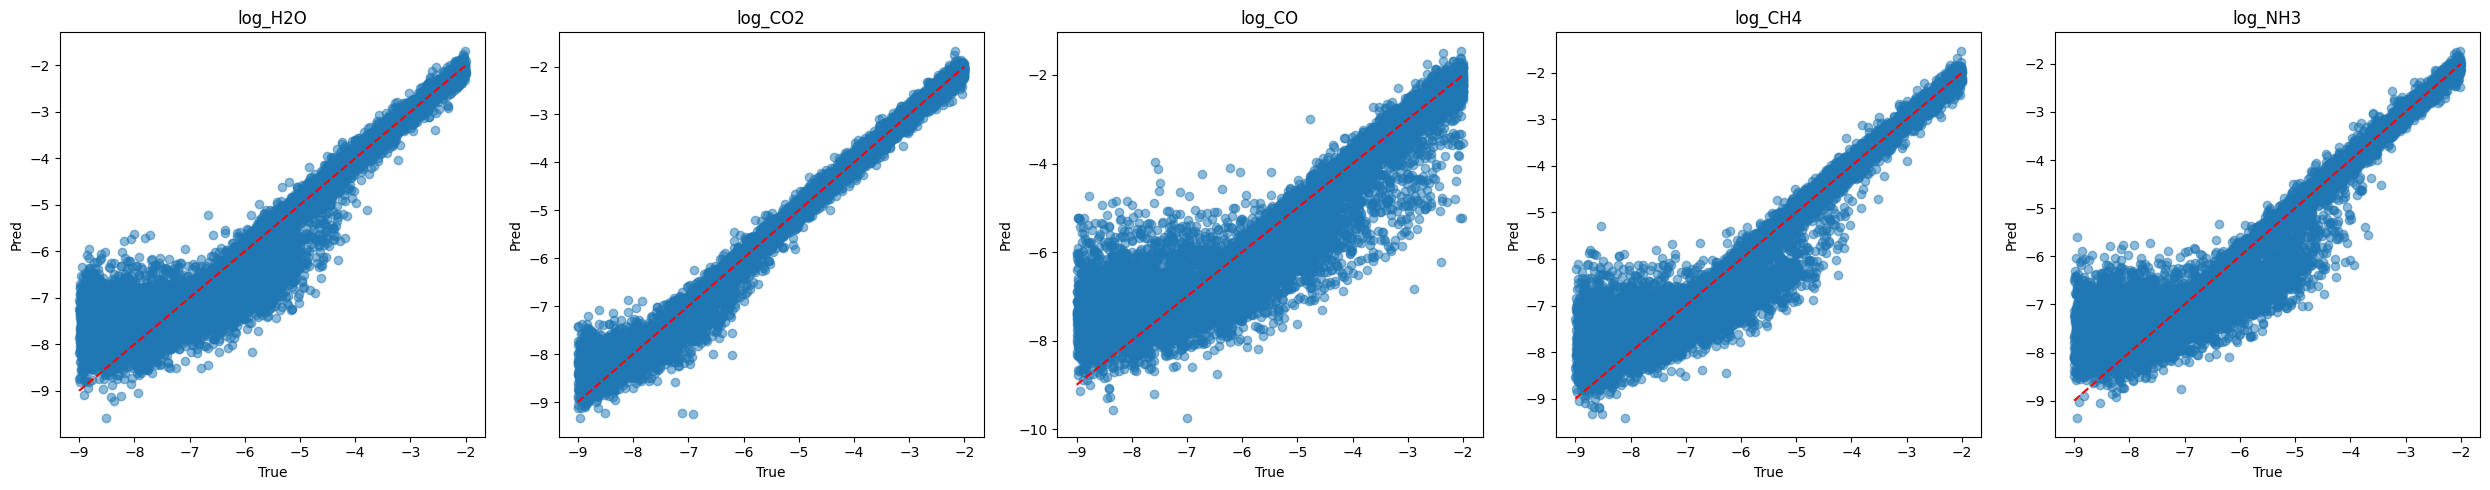

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25,5))
for i, col in enumerate(target_cols):
    axes[i].scatter(y_test_rescaled[:, i], y_pred_rescaled[:, i], alpha=0.5)
    axes[i].plot([y_test_rescaled[:, i].min(), y_test_rescaled[:, i].max()],
                 [y_test_rescaled[:, i].min(), y_test_rescaled[:, i].max()], 'r--')
    axes[i].set_title(col)
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Pred")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Pick 15 random indices
indices = np.random.choice(len(X_test), size=15, replace=False)

print("\nPredictions on 15 random test samples:\n")

for idx in indices:
    sample = X_test[idx].reshape(1, -1)
    y_pred = model.predict(sample, verbose=0)

    y_pred_rescaled = scaler_y.inverse_transform(y_pred)
    y_true_rescaled = scaler_y.inverse_transform(y_test[idx].reshape(1, -1))

    print(f"Sample {idx}:")
    for i, col in enumerate(target_cols):
        print(f"  {col}: Pred={y_pred_rescaled[0][i]:.3f}, True={y_true_rescaled[0][i]:.3f}")
    print("-"*50)



Predictions on 15 random test samples:

Sample 7435:
  log_H2O: Pred=-9.132, True=-8.430
  log_CO2: Pred=-7.666, True=-7.746
  log_CO: Pred=-8.380, True=-8.947
  log_CH4: Pred=-7.240, True=-7.224
  log_NH3: Pred=-7.771, True=-7.785
--------------------------------------------------
Sample 5902:
  log_H2O: Pred=-4.132, True=-4.135
  log_CO2: Pred=-8.222, True=-8.773
  log_CO: Pred=-7.236, True=-8.702
  log_CH4: Pred=-6.736, True=-7.899
  log_NH3: Pred=-4.121, True=-4.278
--------------------------------------------------
Sample 938:
  log_H2O: Pred=-6.630, True=-8.622
  log_CO2: Pred=-5.317, True=-5.296
  log_CO: Pred=-7.361, True=-8.991
  log_CH4: Pred=-5.735, True=-5.127
  log_NH3: Pred=-2.686, True=-2.718
--------------------------------------------------
Sample 2933:
  log_H2O: Pred=-2.373, True=-2.212
  log_CO2: Pred=-7.447, True=-6.879
  log_CO: Pred=-6.617, True=-6.391
  log_CH4: Pred=-4.780, True=-4.718
  log_NH3: Pred=-3.295, True=-3.158
---------------------------------------

In [ ]:
# import os

# save_dir = "/content/drive/MyDrive/saved_models"
# os.makedirs(save_dir, exist_ok=True)

# # Save in Keras format
# model.save(os.path.join(save_dir, "quantum_regression_model.keras"))

# #  save in H5 format
# model.save(os.path.join(save_dir, "quantum_regression_model.h5"))


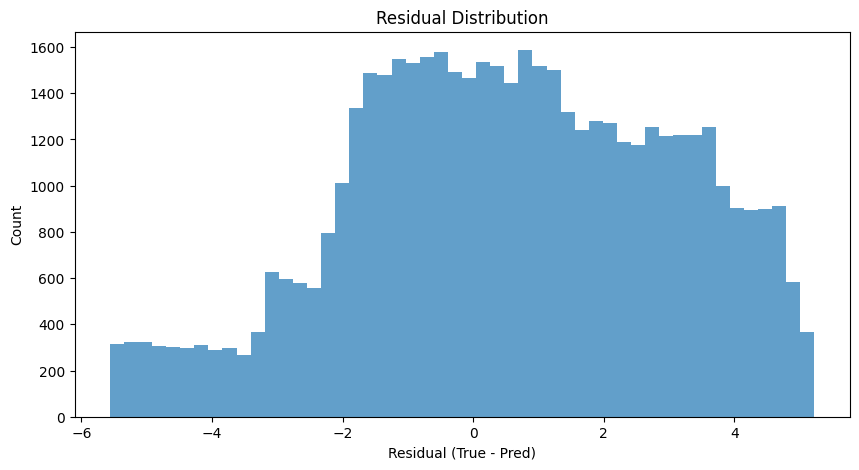

In [ ]:
residuals = y_test_rescaled - y_pred_rescaled
plt.figure(figsize=(10,5))
plt.hist(residuals.flatten(), bins=50, alpha=0.7)
plt.xlabel("Residual (True - Pred)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()


In [ ]:
y_shuffled = np.random.permutation(y_train)

# Train again for a few epochs with shuffled labels
history_shuf = model.fit(
    X_train, y_shuffled,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=64, verbose=1
)

# Evaluate performance
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Performance with shuffled labels -> Loss:", loss, "MAE:", mae)

Epoch 1/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 1.8695 - mae: 1.1168 - val_loss: 0.0977 - val_mae: 0.2000
Epoch 2/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 1.7989 - mae: 1.0965 - val_loss: 0.1055 - val_mae: 0.2129
Epoch 3/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 1.7548 - mae: 1.0840 - val_loss: 0.1160 - val_mae: 0.2306
Epoch 4/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.7009 - mae: 1.0686 - val_loss: 0.1280 - val_mae: 0.2472
Epoch 5/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 1.6564 - mae: 1.0549 - val_loss: 0.1411 - val_mae: 0.2653
Performance with shuffled labels -> Loss: 0.14055266976356506 MAE: 0.2663288712501526
